**Cell 1**

In [24]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive', force_remount=True)

BASE = Path("/content/drive/MyDrive/trellis_project")
for p in [
    BASE,
    BASE / "hf_cache",
    BASE / "outputs",
    BASE / "outputs" / "trellis2_smoke",
    BASE / "data",
    BASE / "models",
    BASE / "logs",
    BASE / "notebooks",
    BASE / "results",
]:
    p.mkdir(parents=True, exist_ok=True)

env_file = BASE / "trellis2_env.sh"
env_file.write_text(
    "\n".join([
        "export HF_HOME=/content/drive/MyDrive/trellis_project/hf_cache",
        "export TORCH_HOME=/content/drive/MyDrive/trellis_project/hf_cache",
        "export SPCONV_ALGO=native",
        "export SPARSE_CONV_BACKEND=spconv",
        "export SPARSE_ATTN_BACKEND=flash_attn",
        "export ATTN_BACKEND=flash_attn",
        "export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True",
        "export OPENCV_IO_ENABLE_OPENEXR=1",
        "",
    ])
)

print("Base:", BASE)
print("Env file:", env_file)


Mounted at /content/drive
Base: /content/drive/MyDrive/trellis_project
Env file: /content/drive/MyDrive/trellis_project/trellis2_env.sh


Cell **2**

In [25]:
!nvidia-smi -L
!nvidia-smi

GPU 0: NVIDIA RTX PRO 6000 Blackwell Server Edition (UUID: GPU-9d5ef3e1-0938-e018-1e36-1c5a2c45a3db)
Wed Mar 18 23:26:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             46W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                      

Cell 3

In [26]:
%%bash
set -euo pipefail

if [ ! -x /usr/local/miniforge/bin/conda ]; then
  wget -q https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh -O /tmp/miniforge.sh
  bash /tmp/miniforge.sh -b -p /usr/local/miniforge
fi

source /usr/local/miniforge/etc/profile.d/conda.sh
conda --version

conda 26.1.0


Cell 4

In [27]:
%%bash
set -euo pipefail

source /usr/local/miniforge/etc/profile.d/conda.sh

conda env remove -n trellis2 -y || true
conda create -n trellis2 python=3.10 -y

conda run -n trellis2 python -V


Remove all packages in environment /usr/local/miniforge/envs/trellis2:


## Package Plan ##

  environment location: /usr/local/miniforge/envs/trellis2


The following packages will be REMOVED:

  _openmp_mutex-4.5-20_gnu
  bzip2-1.0.8-hda65f42_9
  ca-certificates-2026.2.25-hbd8a1cb_0
  icu-78.3-h33c6efd_0
  ld_impl_linux-64-2.45.1-default_hbd61a6d_101
  libexpat-2.7.4-hecca717_0
  libffi-3.5.2-h3435931_0
  libgcc-15.2.0-he0feb66_18
  libgcc-ng-15.2.0-h69a702a_18
  libgomp-15.2.0-he0feb66_18
  liblzma-5.8.2-hb03c661_0
  libnsl-2.0.1-hb9d3cd8_1
  libsqlite-3.52.0-hf4e2dac_0
  libstdcxx-15.2.0-h934c35e_18
  libuuid-2.41.3-h5347b49_0
  libxcrypt-4.4.36-hd590300_1
  libzlib-1.3.1-hb9d3cd8_2
  ncurses-6.5-h2d0b736_3
  openssl-3.6.1-h35e630c_1
  packaging-26.0-pyhcf101f3_0
  pip-26.0.1-pyh8b19718_0
  python-3.10.20-h3c07f61_0_cpython
  readline-8.3-h853b02a_0
  setuptools-82.0.1-pyh332efcf_0
  tk-8.6.13-noxft_h366c992_103
  tzdata-2025c-hc9c84f9_1
  wheel-0.46.3-pyhd8ed1ab_0
  zstd-1.5.7-hb



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.0
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda




Cell 5

In [28]:
%%bash
set -euo pipefail

apt-get update -y
apt-get install -y libjpeg-dev git git-lfs ffmpeg

source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis2

pip install --upgrade pip setuptools wheel packaging ninja
pip install --no-cache-dir \
  torch==2.8.0 \
  torchvision==0.23.0 \
  torchaudio==2.8.0 \
  --index-url https://download.pytorch.org/whl/cu128

python - <<'PY'
import torch
print("torch:", torch.__version__)
print("cuda from torch:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    a = torch.randn((1024, 1024), device="cuda", dtype=torch.float16)
    b = torch.randn((1024, 1024), device="cuda", dtype=torch.float16)
    c = a @ b
    print("matmul ok:", c.shape, c.dtype, float(c.abs().mean()))
PY

Hit:1 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Hit:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Reading package lists...
Reading package lists...
Building dependency tree...
Reading state information...
libjpeg-dev is already the newest version (8c-2ubuntu10).
git is already the newest version (1:2.34.1-1ubuntu1.17).
ffmpeg is 

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Cell 6

In [29]:
%%bash
set -euo pipefail

rm -rf /content/TRELLIS2

git clone -b main --recursive https://github.com/microsoft/TRELLIS.2.git /content/TRELLIS2
cd /content/TRELLIS2

git rev-parse HEAD | tee /content/drive/MyDrive/trellis_project/logs/trellis2_commit.txt

Submodule path 'o-voxel/third_party/eigen': checked out '21e4582d1739107337a03460c81412981130373e'
5565d240c4a494caaf9ece7a554542b76ffa36d3


Cloning into '/content/TRELLIS2'...
Submodule 'o-voxel/third_party/eigen' (https://gitlab.com/libeigen/eigen.git) registered for path 'o-voxel/third_party/eigen'
Cloning into '/content/TRELLIS2/o-voxel/third_party/eigen'...


Cell 7

In [30]:
%%bash
set -euo pipefail

source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis2
source /content/drive/MyDrive/trellis_project/trellis2_env.sh

pip install --no-cache-dir \
  imageio \
  imageio-ffmpeg \
  tqdm \
  easydict \
  opencv-python-headless \
  trimesh \
  transformers \
  gradio==6.0.1 \
  tensorboard \
  pandas \
  lpips \
  zstandard \
  kornia \
  timm

pip install --no-cache-dir \
  git+https://github.com/EasternJournalist/utils3d.git@9a4eb15e4021b67b12c460c7057d642626897ec8

pip uninstall -y pillow || true
CC=cc pip install --no-cache-dir pillow-simd

python - <<'PY'
import transformers, cv2, imageio, timm, kornia
print("basic deps ok")
PY

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 63.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 490.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 1.5 GB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 343.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 664.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 948.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.5/29.5 MB 348.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 144.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 1.7 GB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 404.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 331.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 267.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 574.0 MB/s  0:00:00
   ━━━━━

  Running command git clone --filter=blob:none --quiet https://github.com/EasternJournalist/utils3d.git /tmp/pip-req-build-59mnyc1h
  Running command git rev-parse -q --verify 'sha^9a4eb15e4021b67b12c460c7057d642626897ec8'
  Running command git fetch -q https://github.com/EasternJournalist/utils3d.git 9a4eb15e4021b67b12c460c7057d642626897ec8
  Running command git checkout -q 9a4eb15e4021b67b12c460c7057d642626897ec8


Cell 8

In [31]:
%%bash
set -euo pipefail

echo "=== host GPU check ==="
nvidia-smi || true
echo
ls -l /dev/nvidia* || true
echo

echo "=== rewrite env file for Colab GPU visibility + xformers backend ==="
cat > /content/drive/MyDrive/trellis_project/trellis2_env.sh <<'EOF'
export HF_HOME=/content/drive/MyDrive/trellis_project/hf_cache
export TORCH_HOME=/content/drive/MyDrive/trellis_project/hf_cache
export SPCONV_ALGO=native

# TRELLIS.2 backend choice
export SPARSE_CONV_BACKEND=spconv
export SPARSE_ATTN_BACKEND=xformers
export ATTN_BACKEND=xformers

# Colab / NVIDIA paths
export PATH=/usr/local/nvidia/bin:/usr/local/cuda/bin:$PATH
export LD_LIBRARY_PATH=/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/lib64-nvidia:/usr/lib/x86_64-linux-gnu:${LD_LIBRARY_PATH:-}

# runtime behavior
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
export OPENCV_IO_ENABLE_OPENEXR=1
EOF

echo "=== activate env ==="
source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis2
source /content/drive/MyDrive/trellis_project/trellis2_env.sh

echo "python: $(which python)"
echo "PATH=$PATH"
echo "LD_LIBRARY_PATH=$LD_LIBRARY_PATH"
echo

echo "=== torch cuda re-check ==="
python - <<'PY'
import os
import ctypes.util
import torch

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("libcuda:", ctypes.util.find_library("cuda"))
print("libnvidia-ml:", ctypes.util.find_library("nvidia-ml"))

if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    a = torch.randn((1024, 1024), device="cuda", dtype=torch.float16)
    b = torch.randn((1024, 1024), device="cuda", dtype=torch.float16)
    c = a @ b
    print("matmul ok:", c.shape, c.dtype, float(c.abs().mean()))
else:
    raise SystemExit("CUDA is still not visible inside the trellis2 env.")
PY

=== host GPU check ===
Wed Mar 18 23:29:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   30C    P0             46W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+------------------------

Cell 9

In [32]:
%%bash
set -euo pipefail

source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis2

rm -rf /tmp/nvdiffrast
git clone -b v0.4.0 https://github.com/NVlabs/nvdiffrast.git /tmp/nvdiffrast
pip install /tmp/nvdiffrast --no-build-isolation

python - <<'PY'
import nvdiffrast.torch as dr
print("nvdiffrast ok")
PY

Processing /tmp/nvdiffrast
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for nvdiffrast: filename=nvdiffrast-0.4.0-cp310-cp310-linux_x86_64.whl size=1175851 sha256=e9cae01a89cd04af4b8160710024acbd2d200f41586521e9659abaf1007e5984
  Stored in directory: /tmp/pip-ephem-wheel-cache-2jqy5j7t/wheels/90/3e/bd/39e0240ec64099b0d942de2bf38faa4aa2556fbabc77456143
Successfully built nvdiffrast
nvdiffrast ok


Cloning into '/tmp/nvdiffrast'...
Note: switching to '253ac4fcea7de5f396371124af597e6cc957bfae'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false



cell 10

In [33]:
%%bash
set -euo pipefail

source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis2

rm -rf /tmp/nvdiffrec
git clone -b renderutils https://github.com/JeffreyXiang/nvdiffrec.git /tmp/nvdiffrec
pip install /tmp/nvdiffrec --no-build-isolation

python - <<'PY'
print("nvdiffrec install finished")
PY

Processing /tmp/nvdiffrec
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for nvdiffrec_render: filename=nvdiffrec_render-0.0.0-cp310-cp310-linux_x86_64.whl size=919999 sha256=55f585cc813fd2144922e7432cc13b479d7b627204fc7c70771c302e8f3c5e19
  Stored in directory: /tmp/pip-ephem-wheel-cache-b8asqorr/wheels/e5/34/44/01868f2de96a2d3b306a9fa2158466e2f659fe76c41963842e
Successfully built nvdiffrec_render
nvdiffrec install finished


Cloning into '/tmp/nvdiffrec'...


Cell 11

In [34]:
%%bash
set -euo pipefail

source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis2

rm -rf /tmp/CuMesh
git clone --recursive https://github.com/JeffreyXiang/CuMesh.git /tmp/CuMesh
pip install /tmp/CuMesh --no-build-isolation

python - <<'PY'
import cumesh
print("cumesh ok")
PY

Submodule path 'third_party/cubvh': checked out 'ce92267a24ef6ad7d2c8ccbc2ae2c021a6597e70'
Submodule path 'third_party/cubvh/third_party/eigen': checked out 'e63d9f6ccb7f6f29f31241b87c542f3f0ab3112b'
Processing /tmp/CuMesh
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for cumesh: filename=cumesh-0.0.1-cp310-cp310-linux_x86_64.whl size=3896514 sha256=5586ca0b838ef8bbcfc372f55da4ccbac6644c69c48fb21f44fea58c6610795c
  Stored in directory: /tmp/pip-ephem-wheel-cache-uhzavc5f/wheels/1e/2a/94/782d5cb6935e9012aaf01e5ed7bc60b91c8b34e9c830dd0fd0
Successfully built cumesh
cumesh ok


Cloning into '/tmp/CuMesh'...
Submodule 'third_party/cubvh' (https://github.com/JeffreyXiang/cubvh.git) registered for path 'third_party/cubvh'
Cloning into '/tmp/CuMesh/third_party/cubvh'...
Submodule 'third_party/eigen' (https://gitlab.com/libeigen/eigen) registered for path 'third_party/cubvh/third_party/eigen'
Cloning into '/tmp/CuMesh/third_party/cubvh/third_party/eigen'...


Cell 12

In [35]:
%%bash
set -euo pipefail

source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis2

rm -rf /tmp/FlexGEMM
git clone --recursive https://github.com/JeffreyXiang/FlexGEMM.git /tmp/FlexGEMM
pip install /tmp/FlexGEMM --no-build-isolation

python - <<'PY'
import flex_gemm
print("flex_gemm ok")
PY

Processing /tmp/FlexGEMM
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for flex_gemm: filename=flex_gemm-1.0.0-cp310-cp310-linux_x86_64.whl size=247889 sha256=bf1142c9d0d6972ef48a6e6011f28896d5e1681d84869c21ef4dfa9726a803ef
  Stored in directory: /tmp/pip-ephem-wheel-cache-og668khf/wheels/5a/62/a3/00bf13a0738d0c91ceea170fabf82e38ec9d86b0b87c436c0e
Successfully built flex_gemm
flex_gemm ok


Cloning into '/tmp/FlexGEMM'...


Cell 13

In [36]:
%%bash
set -euo pipefail

source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis2

pip install /content/TRELLIS2/o-voxel --no-build-isolation
pip install spconv-cu124==2.3.8

python - <<'PY'
import o_voxel
import spconv.pytorch as spconv
print("o_voxel ok")
print("spconv ok")
PY

Processing ./TRELLIS2/o-voxel
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Cloning https://github.com/JeffreyXiang/CuMesh.git to /tmp/pip-install-oey95ozt/cumesh_7dfc6e5194d947328cba0ddde74a604b
  Resolved https://github.com/JeffreyXiang/CuMesh.git to commit cf1a2f07304b5fe388ed86a16e4a0474599df914
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Cloning https://github.com/JeffreyXiang/FlexGEMM.git to /tmp/pip-install-oey95ozt/flex-gemm_ae52dc7a99a94272a6dfa0c5443feece
  Resolved https://github.com/JeffreyXiang/FlexGEMM.git to commit 9f2f050396be3cc48894d15ce308e9672a07c677
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for o_voxel: filename=o_voxel-0.0.1-cp310-cp310-linux_x86_64.whl size=264092 sha256=dcdc8ad45080dd2021c3cd5ee13b9015edc61b1a11e2cb4dc986a3eaa1065927
  

  Running command git clone --filter=blob:none --quiet https://github.com/JeffreyXiang/CuMesh.git /tmp/pip-install-oey95ozt/cumesh_7dfc6e5194d947328cba0ddde74a604b
  Running command git submodule update --init --recursive -q
  Running command git clone --filter=blob:none --quiet https://github.com/JeffreyXiang/FlexGEMM.git /tmp/pip-install-oey95ozt/flex-gemm_ae52dc7a99a94272a6dfa0c5443feece


Cell 14

In [37]:
%%bash
set -euo pipefail

source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis2
source /content/drive/MyDrive/trellis_project/trellis2_env.sh

export PYTHONPATH=/content/TRELLIS2:${PYTHONPATH:-}

python - <<'PY'
import os
import torch

print("GPU:", torch.cuda.get_device_name(0))
print("SPARSE_CONV_BACKEND:", os.environ.get("SPARSE_CONV_BACKEND"))
print("SPARSE_ATTN_BACKEND:", os.environ.get("SPARSE_ATTN_BACKEND"))

from trellis2.pipelines import Trellis2ImageTo3DPipeline
from trellis2.utils import render_utils
from trellis2.renderers import EnvMap
import o_voxel, cumesh, flex_gemm, nvdiffrast.torch as dr

print("TRELLIS.2 import smoke test: OK")
PY

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
SPARSE_CONV_BACKEND: spconv
SPARSE_ATTN_BACKEND: xformers
[SPARSE] Conv backend: spconv; Attention backend: xformers
TRELLIS.2 import smoke test: OK


Trellis test cell 1

In [38]:
%%bash
set -euo pipefail

source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis2
source /content/drive/MyDrive/trellis_project/trellis2_env.sh

echo "=== remove conflicting xformers ==="
pip uninstall -y xformers || true

echo
echo "=== restore pinned torch stack ==="
pip install --no-cache-dir --force-reinstall \
  torch==2.8.0 \
  torchvision==0.23.0 \
  torchaudio==2.8.0 \
  --index-url https://download.pytorch.org/whl/cu128

echo
echo "=== install xformers without touching torch ==="
pip install --no-cache-dir --no-deps \
  xformers==0.0.32.post2 \
  --index-url https://download.pytorch.org/whl/cu128

echo
echo "=== verify torch + xformers ==="
python - <<'PY'
import torch
import xformers

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
print("xformers:", getattr(xformers, "__version__", "unknown"))
PY

=== remove conflicting xformers ===

=== restore pinned torch stack ===
Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 276.1 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 316.4 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 294.5 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 284.9 MB/s  0:00:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 280.8 MB/s  0:00:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 285.3 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 292.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 277.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 283.1 MB/s  0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 284.5 MB/s  0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 188.

In [39]:
%%bash
set -euo pipefail

source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis2
source /content/drive/MyDrive/trellis_project/trellis2_env.sh

export PYTHONPATH=/content/TRELLIS2:${PYTHONPATH:-}

cd /content/TRELLIS2

python - <<'PY'
import os
import cv2
import torch
import importlib
from pathlib import Path

print("=== torch ===")
print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if not torch.cuda.is_available():
    raise SystemExit("CUDA is not visible. Stop here.")
print("gpu:", torch.cuda.get_device_name(0))

print("\n=== env backends ===")
print("SPARSE_CONV_BACKEND =", os.environ.get("SPARSE_CONV_BACKEND"))
print("SPARSE_ATTN_BACKEND =", os.environ.get("SPARSE_ATTN_BACKEND"))
print("ATTN_BACKEND        =", os.environ.get("ATTN_BACKEND"))

print("\n=== import checks ===")
mods = [
    "xformers",
    "spconv.pytorch",
    "nvdiffrast.torch",
    "cumesh",
    "flex_gemm",
    "o_voxel",
    "trellis2",
    "trellis2.pipelines",
    "trellis2.utils.render_utils",
    "trellis2.renderers",
]
for m in mods:
    importlib.import_module(m)
    print("OK:", m)

print("\n=== local asset checks ===")
hdr = Path("assets/hdri/forest.exr")
img = Path("assets/example_image/T.png")
print("forest.exr exists:", hdr.exists(), hdr)
print("example image exists:", img.exists(), img)
if not hdr.exists():
    raise SystemExit("Missing assets/hdri/forest.exr")
if not img.exists():
    raise SystemExit("Missing assets/example_image/T.png")

exr = cv2.imread(str(hdr), cv2.IMREAD_UNCHANGED)
if exr is None:
    raise SystemExit("OpenCV failed to read forest.exr")
print("forest.exr shape:", exr.shape, "dtype:", exr.dtype)

print("\n=== envmap GPU load test ===")
from trellis2.renderers import EnvMap
env = EnvMap(torch.tensor(
    cv2.cvtColor(exr, cv2.COLOR_BGR2RGB),
    dtype=torch.float32,
    device="cuda"
))
print("EnvMap loaded on GPU")

print("\n=== tiny CUDA matmul ===")
a = torch.randn((512, 512), device="cuda", dtype=torch.float16)
b = torch.randn((512, 512), device="cuda", dtype=torch.float16)
c = a @ b
print("matmul ok:", c.shape, c.dtype, float(c.abs().mean()))

print("\nLOCAL TRELLIS STACK SMOKE TEST PASSED")
PY

=== torch ===
torch: 2.8.0+cu128
torch cuda: 12.8
cuda available: True
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition

=== env backends ===
SPARSE_CONV_BACKEND = spconv
SPARSE_ATTN_BACKEND = xformers
ATTN_BACKEND        = xformers

=== import checks ===
OK: xformers
OK: spconv.pytorch
OK: nvdiffrast.torch
OK: cumesh
OK: flex_gemm
OK: o_voxel
OK: trellis2
OK: trellis2.pipelines
OK: trellis2.utils.render_utils
OK: trellis2.renderers

=== local asset checks ===
forest.exr exists: True assets/hdri/forest.exr
example image exists: True assets/example_image/T.png
forest.exr shape: (512, 1024, 3) dtype: float32

=== envmap GPU load test ===
EnvMap loaded on GPU

=== tiny CUDA matmul ===
matmul ok: torch.Size([512, 512]) torch.float16 18.046875

LOCAL TRELLIS STACK SMOKE TEST PASSED


Trellis test cell 2

In [40]:
%%bash
set -euo pipefail

source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis2
source /content/drive/MyDrive/trellis_project/trellis2_env.sh

export PYTHONPATH=/content/TRELLIS2:${PYTHONPATH:-}

python - <<'PY'
import json
from pathlib import Path
import torch

out = Path("/content/drive/MyDrive/trellis_project/outputs/trellis2_smoke")
out.mkdir(parents=True, exist_ok=True)

meta = {
    "torch": torch.__version__,
    "cuda": torch.version.cuda,
    "cuda_available": torch.cuda.is_available(),
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "status": "local_stack_ok",
}
p = out / "local_stack_check.json"
p.write_text(json.dumps(meta, indent=2))
print("WROTE", p)
print(p.read_text())
PY

WROTE /content/drive/MyDrive/trellis_project/outputs/trellis2_smoke/local_stack_check.json
{
  "torch": "2.8.0+cu128",
  "cuda": "12.8",
  "cuda_available": true,
  "gpu": "NVIDIA RTX PRO 6000 Blackwell Server Edition",
  "status": "local_stack_ok"
}


Cell 14.5

In [41]:
from getpass import getpass
from pathlib import Path
import os

from huggingface_hub import login, hf_hub_download

HF_TOKEN = getpass("Paste your Hugging Face token: ").strip()

os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["HUGGINGFACE_HUB_TOKEN"] = HF_TOKEN

login(token=HF_TOKEN, add_to_git_credential=False)

cache_dir = "/content/drive/MyDrive/trellis_project/hf_cache"
Path(cache_dir).mkdir(parents=True, exist_ok=True)

checks = [
    ("microsoft/TRELLIS.2-4B", "pipeline.json"),
    ("facebook/dinov3-vitl16-pretrain-lvd1689m", "config.json"),
    ("briaai/RMBG-2.0", "config.json"),
]

for repo_id, filename in checks:
    path = hf_hub_download(
        repo_id=repo_id,
        filename=filename,
        token=HF_TOKEN,
        cache_dir=cache_dir,
    )
    print(f"OK: {repo_id} -> {path}")

print("\nHF auth + all gated access checks passed.")

Paste your Hugging Face token: ··········


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


OK: microsoft/TRELLIS.2-4B -> /content/drive/MyDrive/trellis_project/hf_cache/models--microsoft--TRELLIS.2-4B/snapshots/af44b45f2e35a493886929c6d786e563ec68364d/pipeline.json
OK: facebook/dinov3-vitl16-pretrain-lvd1689m -> /content/drive/MyDrive/trellis_project/hf_cache/models--facebook--dinov3-vitl16-pretrain-lvd1689m/snapshots/ea8dc2863c51be0a264bab82070e3e8836b02d51/config.json
OK: briaai/RMBG-2.0 -> /content/drive/MyDrive/trellis_project/hf_cache/models--briaai--RMBG-2.0/snapshots/4bc511b89a830612100db4e22d93712c3ae7befa/config.json

HF auth + all gated access checks passed.


Cell 14.91

In [42]:
from pathlib import Path
import shutil

target = Path("/content/TRELLIS2/trellis2/pipelines/trellis2_image_to_3d.py")
backup = Path("/content/TRELLIS2/trellis2/pipelines/trellis2_image_to_3d.py.bak")

if not backup.exists():
    shutil.copy2(target, backup)

text = target.read_text()

old = "pipeline.rembg_model = getattr(rembg, args['rembg_model']['name'])(**args['rembg_model']['args'])"
new = "pipeline.rembg_model = None  # patched for Colab smoke test: skip BRIA rembg eager load"

if old not in text:
    raise RuntimeError("Expected rembg init line not found. Stop here and send this cell output.")

text = text.replace(old, new)
target.write_text(text)

print("Patched:", target)
print("\n--- verification line ---")
for line in target.read_text().splitlines():
    if "pipeline.rembg_model" in line:
        print(line)

Patched: /content/TRELLIS2/trellis2/pipelines/trellis2_image_to_3d.py

--- verification line ---
        pipeline.rembg_model = None  # patched for Colab smoke test: skip BRIA rembg eager load


Cell 14.92

In [43]:
from pathlib import Path
import os

env_file = Path("/content/drive/MyDrive/trellis_project/trellis2_env.sh")

lines = []
for line in env_file.read_text().splitlines():
    if line.startswith("export SPARSE_ATTN_BACKEND="):
        lines.append("export SPARSE_ATTN_BACKEND=sdpa")
    elif line.startswith("export ATTN_BACKEND="):
        lines.append("export ATTN_BACKEND=sdpa")
    else:
        lines.append(line)

env_file.write_text("\n".join(lines) + "\n")

os.environ["SPARSE_ATTN_BACKEND"] = "sdpa"
os.environ["ATTN_BACKEND"] = "sdpa"

print(env_file.read_text())
print("Notebook env override:")
print("SPARSE_ATTN_BACKEND =", os.environ["SPARSE_ATTN_BACKEND"])
print("ATTN_BACKEND        =", os.environ["ATTN_BACKEND"])

export HF_HOME=/content/drive/MyDrive/trellis_project/hf_cache
export TORCH_HOME=/content/drive/MyDrive/trellis_project/hf_cache
export SPCONV_ALGO=native

# TRELLIS.2 backend choice
export SPARSE_CONV_BACKEND=spconv
export SPARSE_ATTN_BACKEND=sdpa
export ATTN_BACKEND=sdpa

# Colab / NVIDIA paths
export PATH=/usr/local/nvidia/bin:/usr/local/cuda/bin:$PATH
export LD_LIBRARY_PATH=/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/lib64-nvidia:/usr/lib/x86_64-linux-gnu:${LD_LIBRARY_PATH:-}

# runtime behavior
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
export OPENCV_IO_ENABLE_OPENEXR=1

Notebook env override:
SPARSE_ATTN_BACKEND = sdpa
ATTN_BACKEND        = sdpa


Cell 14.94

In [47]:
from pathlib import Path
import subprocess

repo = Path("/content/TRELLIS2")
cfg = repo / "trellis2/modules/sparse/config.py"
attn = repo / "trellis2/modules/sparse/attention/full_attn.py"
py = "/usr/local/miniforge/envs/trellis2/bin/python"

# 1) restore both sparse files to clean repo state
subprocess.run(
    ["git", "checkout", "--", "trellis2/modules/sparse/config.py", "trellis2/modules/sparse/attention/full_attn.py"],
    cwd=repo,
    check=True,
)

# 2) patch config.py to allow sdpa
cfg_text = cfg.read_text()

old = "if env_sparse_attn_backend is not None and env_sparse_attn_backend in ['xformers', 'flash_attn', 'flash_attn_3']:"
new = "if env_sparse_attn_backend is not None and env_sparse_attn_backend in ['xformers', 'flash_attn', 'flash_attn_3', 'sdpa']:"
if old not in cfg_text:
    raise RuntimeError("config.py whitelist line not found")
cfg_text = cfg_text.replace(old, new, 1)

old = "def set_attn_backend(backend: Literal['xformers', 'flash_attn']):"
new = "def set_attn_backend(backend: Literal['xformers', 'flash_attn', 'flash_attn_3', 'sdpa']):"
if old in cfg_text:
    cfg_text = cfg_text.replace(old, new, 1)

cfg.write_text(cfg_text)

# 3) patch full_attn.py with CORRECTLY INDENTED sdpa branch
attn_text = attn.read_text()

marker = "    elif config.ATTN == 'flash_attn_3':"
if marker not in attn_text:
    raise RuntimeError("Indented flash_attn_3 marker not found in full_attn.py")

sdpa_branch = """
    elif config.ATTN == 'sdpa':
        if num_all_args == 1:
            q, k, v = qkv.unbind(dim=1)
        elif num_all_args == 2:
            k, v = kv.unbind(dim=1)

        outs = []
        q_offset = 0
        kv_offset = 0

        for qs, ks in zip(q_seqlen, kv_seqlen):
            q_i = q[q_offset:q_offset + qs].permute(1, 0, 2).unsqueeze(0)
            k_i = k[kv_offset:kv_offset + ks].permute(1, 0, 2).unsqueeze(0)
            v_i = v[kv_offset:kv_offset + ks].permute(1, 0, 2).unsqueeze(0)

            out_i = torch.nn.functional.scaled_dot_product_attention(q_i, k_i, v_i)
            out_i = out_i.squeeze(0).permute(1, 0, 2)
            outs.append(out_i)

            q_offset += qs
            kv_offset += ks

        out = torch.cat(outs, dim=0)

"""

attn_text = attn_text.replace(marker, sdpa_branch + marker, 1)
attn.write_text(attn_text)

# 4) compile each file separately so we see the real result
print("Checking:", cfg)
r1 = subprocess.run([py, "-m", "py_compile", str(cfg)], capture_output=True, text=True)
print("config.py rc =", r1.returncode)
print(r1.stdout)
print(r1.stderr)

print("Checking:", attn)
r2 = subprocess.run([py, "-m", "py_compile", str(attn)], capture_output=True, text=True)
print("full_attn.py rc =", r2.returncode)
print(r2.stdout)
print(r2.stderr)

if r1.returncode != 0 or r2.returncode != 0:
    raise RuntimeError("py_compile failed; send this cell output")

# 5) quick verification snippet
print("\n--- inserted snippet check ---")
text = attn.read_text()
start = text.index("    elif config.ATTN == 'sdpa':")
end = text.index("    elif config.ATTN == 'flash_attn_3':")
print(text[start:end])

print("OK: sparse config + full_attn patch compiled cleanly")

Checking: /content/TRELLIS2/trellis2/modules/sparse/config.py
config.py rc = 0


Checking: /content/TRELLIS2/trellis2/modules/sparse/attention/full_attn.py
full_attn.py rc = 0



--- inserted snippet check ---
    elif config.ATTN == 'sdpa':
        if num_all_args == 1:
            q, k, v = qkv.unbind(dim=1)
        elif num_all_args == 2:
            k, v = kv.unbind(dim=1)

        outs = []
        q_offset = 0
        kv_offset = 0

        for qs, ks in zip(q_seqlen, kv_seqlen):
            q_i = q[q_offset:q_offset + qs].permute(1, 0, 2).unsqueeze(0)
            k_i = k[kv_offset:kv_offset + ks].permute(1, 0, 2).unsqueeze(0)
            v_i = v[kv_offset:kv_offset + ks].permute(1, 0, 2).unsqueeze(0)

            out_i = torch.nn.functional.scaled_dot_product_attention(q_i, k_i, v_i)
            out_i = out_i.squeeze(0).permute(1, 0, 2)
            outs.append(out_i)

            q_offset += qs
            kv_offset += ks

        out = torch.cat(outs, dim=0)


OK: sparse config

Cell 14.95

In [50]:
from pathlib import Path
import subprocess, os, tempfile, textwrap

env_file = Path("/content/drive/MyDrive/trellis_project/trellis2_env.sh")

gcc = Path("/usr/bin/gcc")
gxx = Path("/usr/bin/g++")
apt = Path("/usr/bin/apt-get")

print("gcc exists:", gcc.exists(), gcc)
print("g++ exists:", gxx.exists(), gxx)
print("apt-get exists:", apt.exists(), apt)

# Install only if compiler is actually missing
if not gcc.exists() or not gxx.exists():
    if not apt.exists():
        raise RuntimeError("Neither gcc/g++ nor /usr/bin/apt-get is available. Send this cell output.")
    subprocess.run([str(apt), "update", "-y"], check=True)
    subprocess.run([str(apt), "install", "-y", "build-essential"], check=True)

# Make compiler visible in both notebook and child process
os.environ["PATH"] = "/usr/bin:/bin:" + os.environ.get("PATH", "")
os.environ["CC"] = "/usr/bin/gcc"
os.environ["CXX"] = "/usr/bin/g++"

lines = env_file.read_text().splitlines()
kept = []
saw_path = saw_cc = saw_cxx = False

for line in lines:
    if line.startswith("export PATH="):
        kept.append('export PATH=/usr/bin:/bin:$PATH')
        saw_path = True
    elif line.startswith("export CC="):
        kept.append("export CC=/usr/bin/gcc")
        saw_cc = True
    elif line.startswith("export CXX="):
        kept.append("export CXX=/usr/bin/g++")
        saw_cxx = True
    else:
        kept.append(line)

if not saw_path:
    kept.append('export PATH=/usr/bin:/bin:$PATH')
if not saw_cc:
    kept.append("export CC=/usr/bin/gcc")
if not saw_cxx:
    kept.append("export CXX=/usr/bin/g++")

env_file.write_text("\n".join(kept) + "\n")

# Verify compiler works with an actual tiny build
tmp = Path(tempfile.mkdtemp())
src = tmp / "hello.c"
out = tmp / "hello"
src.write_text(textwrap.dedent("""
#include <stdio.h>
int main() { printf("ok\\n"); return 0; }
""").strip() + "\n")

r = subprocess.run(
    ["/usr/bin/gcc", str(src), "-o", str(out)],
    capture_output=True, text=True
)
print("gcc compile rc =", r.returncode)
print(r.stdout)
print(r.stderr)

if r.returncode != 0:
    raise RuntimeError("gcc test compile failed; send this cell output")

r2 = subprocess.run([str(out)], capture_output=True, text=True)
print("hello rc =", r2.returncode)
print("hello stdout =", r2.stdout.strip())
print("hello stderr =", r2.stderr.strip())

print("\n--- trellis2_env.sh tail ---")
print("\n".join(env_file.read_text().splitlines()[-10:]))

print("\nNotebook env:")
print("PATH =", os.environ["PATH"])
print("CC =", os.environ["CC"])
print("CXX =", os.environ["CXX"])

print("\nOK: compiler is available and exported")

gcc exists: True /usr/bin/gcc
g++ exists: True /usr/bin/g++
apt-get exists: True /usr/bin/apt-get
gcc compile rc = 0


hello rc = 0
hello stdout = ok
hello stderr = 

--- trellis2_env.sh tail ---

# Colab / NVIDIA paths
export PATH=/usr/bin:/bin:$PATH
export LD_LIBRARY_PATH=/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/lib64-nvidia:/usr/lib/x86_64-linux-gnu:${LD_LIBRARY_PATH:-}

# runtime behavior
export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True
export OPENCV_IO_ENABLE_OPENEXR=1
export CC=/usr/bin/gcc
export CXX=/usr/bin/g++

Notebook env:
PATH = /usr/bin:/bin:/usr/local/nvidia/bin:/usr/local/cuda/bin:$PATH
CC = /usr/bin/gcc
CXX = /usr/bin/g++

OK: compiler is available and exported


Cell 15

In [51]:
import os
import subprocess
from pathlib import Path

env_path = "/content/drive/MyDrive/trellis_project/trellis2_env.sh"
with open(env_path, "r") as f:
    for line in f:
        line = line.strip()
        if line.startswith("export "):
            kv = line[len("export "):]
            if "=" in kv:
                k, v = kv.split("=", 1)
                os.environ[k] = v

# force sdpa in notebook process too
os.environ["SPARSE_ATTN_BACKEND"] = "sdpa"
os.environ["ATTN_BACKEND"] = "sdpa"

if not os.environ.get("HF_TOKEN") and not os.environ.get("HUGGINGFACE_HUB_TOKEN"):
    raise RuntimeError("HF token not present in this notebook session. Run the auth cell first.")

repo_root = "/content/TRELLIS2"
env_python = "/usr/local/miniforge/envs/trellis2/bin/python"
script_path = Path("/content/TRELLIS2/run_trellis2_smoke.py")

script_path.write_text(
r'''
import os
import sys
import json
from pathlib import Path

repo_root = "/content/TRELLIS2"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.chdir(repo_root)

# force sdpa in child before importing TRELLIS
os.environ["SPARSE_ATTN_BACKEND"] = "sdpa"
os.environ["ATTN_BACKEND"] = "sdpa"

import cv2
import imageio
import numpy as np
import torch
from PIL import Image

from huggingface_hub import login
from trellis2.pipelines import Trellis2ImageTo3DPipeline
from trellis2.utils import render_utils
from trellis2.renderers import EnvMap
import o_voxel

token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_HUB_TOKEN")
if not token:
    raise RuntimeError("No HF token available in child process.")
login(token=token, add_to_git_credential=False)

out_dir = Path("/content/TRELLIS2/smoke_out")
out_dir.mkdir(parents=True, exist_ok=True)

print("torch:", torch.__version__, flush=True)
print("cuda:", torch.version.cuda, flush=True)
print("gpu:", torch.cuda.get_device_name(0), flush=True)
print("ATTN_BACKEND:", os.environ.get("ATTN_BACKEND"), flush=True)
print("SPARSE_CONV_BACKEND:", os.environ.get("SPARSE_CONV_BACKEND"), flush=True)
print("SPARSE_ATTN_BACKEND:", os.environ.get("SPARSE_ATTN_BACKEND"), flush=True)

# HDRI
exr = cv2.imread("assets/hdri/forest.exr", cv2.IMREAD_UNCHANGED)
envmap = EnvMap(torch.tensor(
    cv2.cvtColor(exr, cv2.COLOR_BGR2RGB),
    dtype=torch.float32,
    device="cuda"
))

# Build RGBA input so TRELLIS can use alpha as mask and skip rembg
img = Image.open("assets/example_image/T.png").convert("RGB")
arr = np.array(img)

# simple smoke-test matte: near-white background -> transparent
rgb_thresh = 245
alpha = np.where(
    (arr[..., 0] >= rgb_thresh) &
    (arr[..., 1] >= rgb_thresh) &
    (arr[..., 2] >= rgb_thresh),
    0,
    255
).astype(np.uint8)

rgba = np.dstack([arr, alpha])
rgba_img = Image.fromarray(rgba, mode="RGBA")
rgba_path = out_dir / "trellis2_smoke_input_rgba.png"
rgba_img.save(rgba_path)
print("WROTE", rgba_path, flush=True)

pipeline = Trellis2ImageTo3DPipeline.from_pretrained("microsoft/TRELLIS.2-4B")
pipeline.cuda()

mesh = pipeline.run(rgba_img, preprocess_image=False)[0]
mesh.simplify(16777216)

video = render_utils.make_pbr_vis_frames(
    render_utils.render_video(mesh, envmap=envmap)
)
mp4_path = out_dir / "trellis2_smoke.mp4"
imageio.mimsave(str(mp4_path), video, fps=15)

glb = o_voxel.postprocess.to_glb(
    vertices=mesh.vertices,
    faces=mesh.faces,
    attr_volume=mesh.attrs,
    coords=mesh.coords,
    attr_layout=mesh.layout,
    voxel_size=mesh.voxel_size,
    aabb=[[-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]],
    decimation_target=500000,
    texture_size=2048,
    remesh=True,
    remesh_band=1,
    remesh_project=0,
    verbose=True,
)
glb_path = out_dir / "trellis2_smoke.glb"
glb.export(str(glb_path), extension_webp=True)

meta = {
    "torch": torch.__version__,
    "cuda": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0),
    "attn_backend": os.environ.get("ATTN_BACKEND"),
    "sparse_conv_backend": os.environ.get("SPARSE_CONV_BACKEND"),
    "sparse_attn_backend": os.environ.get("SPARSE_ATTN_BACKEND"),
    "input_rgba": str(rgba_path),
    "rembg_bypassed_for_smoke_test": True,
}
with open(out_dir / "run_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("WROTE", mp4_path, flush=True)
print("WROTE", glb_path, flush=True)
'''
)

env = os.environ.copy()
env["PYTHONPATH"] = f"{repo_root}:{env.get('PYTHONPATH', '')}"
env["SPARSE_ATTN_BACKEND"] = "sdpa"
env["ATTN_BACKEND"] = "sdpa"

result = subprocess.run(
    [env_python, str(script_path)],
    env=env,
    text=True,
    capture_output=True,
)

print("=== CHILD STDOUT ===")
print(result.stdout)
print("=== CHILD STDERR ===")
print(result.stderr)
print("=== EXIT CODE ===", result.returncode)

if result.returncode != 0:
    raise RuntimeError("TRELLIS.2 smoke run failed. See CHILD STDOUT/STDERR above.")

=== CHILD STDOUT ===
[SPARSE] Conv backend: spconv; Attention backend: sdpa
torch: 2.8.0+cu128
cuda: 12.8
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition
ATTN_BACKEND: sdpa
SPARSE_CONV_BACKEND: spconv
SPARSE_ATTN_BACKEND: sdpa
WROTE /content/TRELLIS2/smoke_out/trellis2_smoke_input_rgba.png
[ATTENTION] Using backend: sdpa
Original mesh: 1835018 vertices, 161184 faces
After filling holes: 1835033 vertices, 161248 faces
Building BVH for current mesh...Done
Cleaning mesh...
Running Dual Contouring...
After remeshing: 875331 vertices, 1674224 faces
After simplifying: 266432 vertices, 454342 faces
Done
Parameterizing new mesh...
Get 63047 clusters after fast clustering
Done
Sampling attributes...Done
Finalizing mesh...Done
WROTE /content/TRELLIS2/smoke_out/trellis2_smoke.mp4
WROTE /content/TRELLIS2/smoke_out/trellis2_smoke.glb

=== CHILD STDERR ===
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.

Loading weigh

Cell 16

In [52]:
%%bash
set -euo pipefail

DEST=/content/drive/MyDrive/trellis_project/outputs/trellis2_smoke
mkdir -p "$DEST"
cp -av /content/TRELLIS2/smoke_out/. "$DEST"/

echo
echo "Final files:"
ls -lah "$DEST"

'/content/TRELLIS2/smoke_out/./trellis2_smoke.glb' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_smoke/./trellis2_smoke.glb'
'/content/TRELLIS2/smoke_out/./trellis2_smoke.mp4' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_smoke/./trellis2_smoke.mp4'
'/content/TRELLIS2/smoke_out/./run_meta.json' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_smoke/./run_meta.json'
'/content/TRELLIS2/smoke_out/./trellis2_smoke_input_rgba.png' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_smoke/./trellis2_smoke_input_rgba.png'

Final files:
total 43M
-rw-------  1 root root  159 Mar 18 23:34 local_stack_check.json
-rw-------+ 1 root root  315 Mar 19 00:20 run_meta.json
-rw-------+ 1 root root  32M Mar 19 00:20 trellis2_smoke.glb
-rw-------+ 1 root root 1.7M Mar 19 00:18 trellis2_smoke_input_rgba.png
-rw-------+ 1 root root 9.8M Mar 19 00:20 trellis2_smoke.mp4


Cell 16.1

In [74]:
from datasets import load_dataset
from itertools import islice
import matplotlib.pyplot as plt

start_idx = 184   # change this to 12, 24, 36, 48, ... to see new images
n_show = 12

ds = load_dataset(
    "timbrooks/instructpix2pix-clip-filtered",
    split="train",
    streaming=True,
)

samples = list(islice(ds, start_idx, start_idx + n_show))

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, ax in enumerate(axes.flat):
    row = samples[i]
    ax.imshow(row["edited_image"])
    ax.set_title(
        f"local_idx={i} | global_idx={start_idx + i}\nedit: {row['edit_prompt'][:55]}",
        fontsize=9
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

for i, row in enumerate(samples):
    print(f"\nlocal_idx={i} | global_idx={start_idx + i}")
    print("original_prompt:", row["original_prompt"][:160])
    print("edit_prompt    :", row["edit_prompt"][:160])
    print("edited_prompt  :", row["edited_prompt"][:160])

Output hidden; open in https://colab.research.google.com to view.

Cell 16.2

Saved source local: /content/TRELLIS2/smoke_out/ip2p_source_input.png
Saved source drive: /content/drive/MyDrive/trellis_project/outputs/ip2p_source_input.png
Saved edited local: /content/TRELLIS2/smoke_out/ip2p_edited_input.png
Saved edited drive: /content/drive/MyDrive/trellis_project/outputs/ip2p_edited_input.png
chosen_idx: 5
edit_prompt: Make the castle a mansion
edited_prompt: Feudal Japan Environment challenge. Takeda mansion


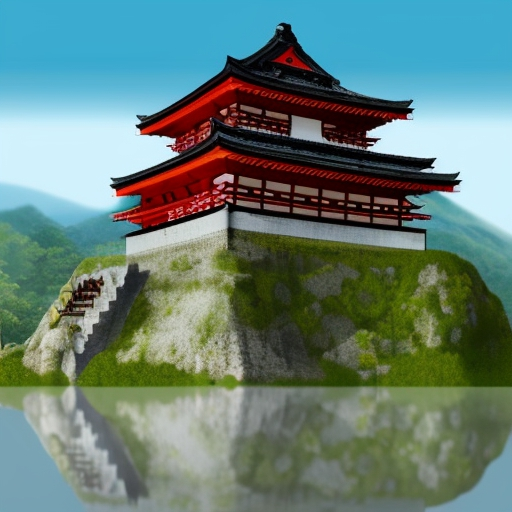

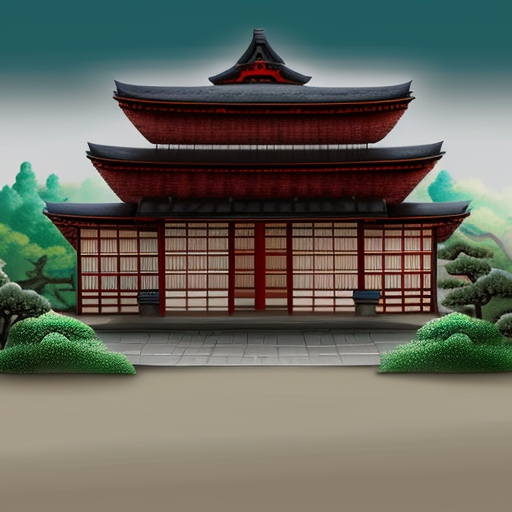

In [75]:
from pathlib import Path
import shutil

chosen_idx = 5  # change this after previewing

local_src = Path("/content/TRELLIS2/smoke_out/ip2p_source_input.png")
local_edit = Path("/content/TRELLIS2/smoke_out/ip2p_edited_input.png")
drive_src = Path("/content/drive/MyDrive/trellis_project/outputs/ip2p_source_input.png")
drive_edit = Path("/content/drive/MyDrive/trellis_project/outputs/ip2p_edited_input.png")

src_img = samples[chosen_idx]["original_image"].convert("RGBA")
edit_img = samples[chosen_idx]["edited_image"].convert("RGBA")

src_img.save(local_src)
edit_img.save(local_edit)

shutil.copy2(local_src, drive_src)
shutil.copy2(local_edit, drive_edit)

print("Saved source local:", local_src)
print("Saved source drive:", drive_src)
print("Saved edited local:", local_edit)
print("Saved edited drive:", drive_edit)
print("chosen_idx:", chosen_idx)
print("edit_prompt:", samples[chosen_idx]["edit_prompt"])
print("edited_prompt:", samples[chosen_idx]["edited_prompt"])

display(src_img)
display(edit_img)

Cell 17

In [57]:
import os
import subprocess
from pathlib import Path

env_path = "/content/drive/MyDrive/trellis_project/trellis2_env.sh"
with open(env_path, "r") as f:
    for line in f:
        line = line.strip()
        if line.startswith("export "):
            kv = line[len("export "):]
            if "=" in kv:
                k, v = kv.split("=", 1)
                os.environ[k] = v

# force sdpa + compiler env in notebook process too
os.environ["SPARSE_ATTN_BACKEND"] = "sdpa"
os.environ["ATTN_BACKEND"] = "sdpa"
os.environ["PATH"] = "/usr/bin:/bin:" + os.environ.get("PATH", "")
os.environ["CC"] = "/usr/bin/gcc"
os.environ["CXX"] = "/usr/bin/g++"

if not os.environ.get("HF_TOKEN") and not os.environ.get("HUGGINGFACE_HUB_TOKEN"):
    raise RuntimeError("HF token not present in this notebook session. Run the auth cell first.")

repo_root = "/content/TRELLIS2"
env_python = "/usr/local/miniforge/envs/trellis2/bin/python"
script_path = Path("/content/TRELLIS2/run_trellis2_ip2p_test.py")

script_path.write_text(
r'''
import os
import sys
import json
from pathlib import Path

repo_root = "/content/TRELLIS2"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.chdir(repo_root)

# force sdpa + compiler env in child before importing TRELLIS
os.environ["SPARSE_ATTN_BACKEND"] = "sdpa"
os.environ["ATTN_BACKEND"] = "sdpa"
os.environ["PATH"] = "/usr/bin:/bin:" + os.environ.get("PATH", "")
os.environ["CC"] = "/usr/bin/gcc"
os.environ["CXX"] = "/usr/bin/g++"

import cv2
import imageio
import torch
from PIL import Image

from huggingface_hub import login
from trellis2.pipelines import Trellis2ImageTo3DPipeline
from trellis2.utils import render_utils
from trellis2.renderers import EnvMap
import o_voxel

token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_HUB_TOKEN")
if not token:
    raise RuntimeError("No HF token available in child process.")
login(token=token, add_to_git_credential=False)

out_dir = Path("/content/TRELLIS2/smoke_out")
out_dir.mkdir(parents=True, exist_ok=True)

print("torch:", torch.__version__, flush=True)
print("cuda:", torch.version.cuda, flush=True)
print("gpu:", torch.cuda.get_device_name(0), flush=True)
print("ATTN_BACKEND:", os.environ.get("ATTN_BACKEND"), flush=True)
print("SPARSE_CONV_BACKEND:", os.environ.get("SPARSE_CONV_BACKEND"), flush=True)
print("SPARSE_ATTN_BACKEND:", os.environ.get("SPARSE_ATTN_BACKEND"), flush=True)
print("CC:", os.environ.get("CC"), flush=True)
print("CXX:", os.environ.get("CXX"), flush=True)

# HDRI
exr = cv2.imread("assets/hdri/forest.exr", cv2.IMREAD_UNCHANGED)
envmap = EnvMap(torch.tensor(
    cv2.cvtColor(exr, cv2.COLOR_BGR2RGB),
    dtype=torch.float32,
    device="cuda"
))

# Use the selected InstructPix2Pix edited image from Cell 16.2
input_path = Path("/content/TRELLIS2/smoke_out/ip2p_test_input.png")
if not input_path.exists():
    raise FileNotFoundError(f"Missing input image: {input_path}. Run Cell 16.2 first.")

rgba_img = Image.open(input_path).convert("RGBA")
rgba_path = out_dir / "trellis2_ip2p_input_rgba.png"
rgba_img.save(rgba_path)
print("WROTE", rgba_path, flush=True)

pipeline = Trellis2ImageTo3DPipeline.from_pretrained("microsoft/TRELLIS.2-4B")
pipeline.cuda()

mesh = pipeline.run(rgba_img, preprocess_image=False)[0]
mesh.simplify(16777216)

video = render_utils.make_pbr_vis_frames(
    render_utils.render_video(mesh, envmap=envmap)
)
mp4_path = out_dir / "trellis2_ip2p_test.mp4"
imageio.mimsave(str(mp4_path), video, fps=15)

glb = o_voxel.postprocess.to_glb(
    vertices=mesh.vertices,
    faces=mesh.faces,
    attr_volume=mesh.attrs,
    coords=mesh.coords,
    attr_layout=mesh.layout,
    voxel_size=mesh.voxel_size,
    aabb=[[-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]],
    decimation_target=500000,
    texture_size=2048,
    remesh=True,
    remesh_band=1,
    remesh_project=0,
    verbose=True,
)
glb_path = out_dir / "trellis2_ip2p_test.glb"
glb.export(str(glb_path), extension_webp=True)

meta = {
    "torch": torch.__version__,
    "cuda": torch.version.cuda,
    "gpu": torch.cuda.get_device_name(0),
    "attn_backend": os.environ.get("ATTN_BACKEND"),
    "sparse_conv_backend": os.environ.get("SPARSE_CONV_BACKEND"),
    "sparse_attn_backend": os.environ.get("SPARSE_ATTN_BACKEND"),
    "cc": os.environ.get("CC"),
    "cxx": os.environ.get("CXX"),
    "input_rgba": str(rgba_path),
    "source_input": str(input_path),
    "dataset_test": "timbrooks/instructpix2pix-clip-filtered",
    "preprocess_image": False,
}
with open(out_dir / "run_meta_ip2p.json", "w") as f:
    json.dump(meta, f, indent=2)

print("WROTE", mp4_path, flush=True)
print("WROTE", glb_path, flush=True)
'''
)

env = os.environ.copy()
env["PYTHONPATH"] = f"{repo_root}:{env.get('PYTHONPATH', '')}"
env["SPARSE_ATTN_BACKEND"] = "sdpa"
env["ATTN_BACKEND"] = "sdpa"
env["PATH"] = "/usr/bin:/bin:" + env.get("PATH", "")
env["CC"] = "/usr/bin/gcc"
env["CXX"] = "/usr/bin/g++"

result = subprocess.run(
    [env_python, str(script_path)],
    env=env,
    text=True,
    capture_output=True,
)

print("=== CHILD STDOUT ===")
print(result.stdout)
print("=== CHILD STDERR ===")
print(result.stderr)
print("=== EXIT CODE ===", result.returncode)

if result.returncode != 0:
    raise RuntimeError("TRELLIS.2 IP2P test run failed. See CHILD STDOUT/STDERR above.")

=== CHILD STDOUT ===
[SPARSE] Conv backend: spconv; Attention backend: sdpa
torch: 2.8.0+cu128
cuda: 12.8
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition
ATTN_BACKEND: sdpa
SPARSE_CONV_BACKEND: spconv
SPARSE_ATTN_BACKEND: sdpa
CC: /usr/bin/gcc
CXX: /usr/bin/g++
WROTE /content/TRELLIS2/smoke_out/trellis2_ip2p_input_rgba.png
[ATTENTION] Using backend: sdpa
Original mesh: 687628 vertices, 82976 faces
After filling holes: 687643 vertices, 83042 faces
Building BVH for current mesh...Done
Cleaning mesh...
Running Dual Contouring...
After remeshing: 432884 vertices, 832084 faces
After simplifying: 243722 vertices, 452878 faces
Done
Parameterizing new mesh...
Get 34491 clusters after fast clustering
Done
Sampling attributes...Done
Finalizing mesh...Done
WROTE /content/TRELLIS2/smoke_out/trellis2_ip2p_test.mp4
WROTE /content/TRELLIS2/smoke_out/trellis2_ip2p_test.glb

=== CHILD STDERR ===
Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token y

Cell 17.1

In [58]:
%%bash
set -euo pipefail

DEST=/content/drive/MyDrive/trellis_project/outputs/trellis2_ip2p_test
mkdir -p "$DEST"

cp -av /content/TRELLIS2/smoke_out/trellis2_ip2p_input_rgba.png "$DEST"/
cp -av /content/TRELLIS2/smoke_out/trellis2_ip2p_test.mp4 "$DEST"/
cp -av /content/TRELLIS2/smoke_out/trellis2_ip2p_test.glb "$DEST"/
cp -av /content/TRELLIS2/smoke_out/run_meta_ip2p.json "$DEST"/

echo
echo "Final files:"
ls -lah "$DEST"

'/content/TRELLIS2/smoke_out/trellis2_ip2p_input_rgba.png' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_ip2p_test/trellis2_ip2p_input_rgba.png'
'/content/TRELLIS2/smoke_out/trellis2_ip2p_test.mp4' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_ip2p_test/trellis2_ip2p_test.mp4'
'/content/TRELLIS2/smoke_out/trellis2_ip2p_test.glb' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_ip2p_test/trellis2_ip2p_test.glb'
'/content/TRELLIS2/smoke_out/run_meta_ip2p.json' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_ip2p_test/run_meta_ip2p.json'

Final files:
total 32M
-rw-------+ 1 root root  481 Mar 19 00:55 run_meta_ip2p.json
-rw-------+ 1 root root 376K Mar 19 00:53 trellis2_ip2p_input_rgba.png
-rw-------+ 1 root root  26M Mar 19 00:55 trellis2_ip2p_test.glb
-rw-------+ 1 root root 4.7M Mar 19 00:55 trellis2_ip2p_test.mp4


18

In [76]:
import os
import subprocess
from pathlib import Path

env_path = "/content/drive/MyDrive/trellis_project/trellis2_env.sh"
with open(env_path, "r") as f:
    for line in f:
        line = line.strip()
        if line.startswith("export "):
            kv = line[len("export "):]
            if "=" in kv:
                k, v = kv.split("=", 1)
                os.environ[k] = v

os.environ["SPARSE_ATTN_BACKEND"] = "sdpa"
os.environ["ATTN_BACKEND"] = "sdpa"
os.environ["PATH"] = "/usr/bin:/bin:" + os.environ.get("PATH", "")
os.environ["CC"] = "/usr/bin/gcc"
os.environ["CXX"] = "/usr/bin/g++"

repo_root = "/content/TRELLIS2"
env_python = "/usr/local/miniforge/envs/trellis2/bin/python"
script_path = Path("/content/TRELLIS2/run_trellis2_source_geom_quality.py")

script_path.write_text(
r'''
import os
import sys
import json
from pathlib import Path

repo_root = "/content/TRELLIS2"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
os.chdir(repo_root)

os.environ["SPARSE_ATTN_BACKEND"] = "sdpa"
os.environ["ATTN_BACKEND"] = "sdpa"
os.environ["PATH"] = "/usr/bin:/bin:" + os.environ.get("PATH", "")
os.environ["CC"] = "/usr/bin/gcc"
os.environ["CXX"] = "/usr/bin/g++"

import cv2
import imageio
import torch
from PIL import Image
from huggingface_hub import login

from trellis2.pipelines import Trellis2ImageTo3DPipeline
from trellis2.utils import render_utils
from trellis2.renderers import EnvMap
import o_voxel

token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_HUB_TOKEN")
if not token:
    raise RuntimeError("No HF token available.")
login(token=token, add_to_git_credential=False)

out_dir = Path("/content/TRELLIS2/smoke_out")
out_dir.mkdir(parents=True, exist_ok=True)

print("torch:", torch.__version__, flush=True)
print("cuda:", torch.version.cuda, flush=True)
print("gpu:", torch.cuda.get_device_name(0), flush=True)
print("ATTN_BACKEND:", os.environ.get("ATTN_BACKEND"), flush=True)
print("SPARSE_ATTN_BACKEND:", os.environ.get("SPARSE_ATTN_BACKEND"), flush=True)

exr = cv2.imread("assets/hdri/forest.exr", cv2.IMREAD_UNCHANGED)
envmap = EnvMap(torch.tensor(
    cv2.cvtColor(exr, cv2.COLOR_BGR2RGB),
    dtype=torch.float32,
    device="cuda"
))

input_path = Path("/content/TRELLIS2/smoke_out/ip2p_source_input.png")
if not input_path.exists():
    raise FileNotFoundError(f"Missing source input: {input_path}. Run Cell 16.2 first.")

rgba_img = Image.open(input_path).convert("RGBA")
rgba_path = out_dir / "trellis2_source_geom_input_rgba.png"
rgba_img.save(rgba_path)
print("WROTE", rgba_path, flush=True)

pipeline = Trellis2ImageTo3DPipeline.from_pretrained("microsoft/TRELLIS.2-4B")
pipeline.cuda()

outputs, latents = pipeline.run(
    rgba_img,
    preprocess_image=False,
    pipeline_type="1536_cascade",
    sparse_structure_sampler_params={
        "steps": 20,
        "guidance_strength": 7.5,
        "guidance_rescale": 0.7,
        "rescale_t": 5.0,
    },
    shape_slat_sampler_params={
        "steps": 20,
        "guidance_strength": 7.5,
        "guidance_rescale": 0.5,
        "rescale_t": 3.0,
    },
    tex_slat_sampler_params={
        "steps": 16,
        "guidance_strength": 1.0,
        "guidance_rescale": 0.0,
        "rescale_t": 3.0,
    },
    return_latent=True,
)

mesh = outputs[0]
mesh.simplify(16777216)

video = render_utils.make_pbr_vis_frames(
    render_utils.render_video(mesh, envmap=envmap)
)
mp4_path = out_dir / "trellis2_source_geom_quality.mp4"
imageio.mimsave(str(mp4_path), video, fps=15)

glb = o_voxel.postprocess.to_glb(
    vertices=mesh.vertices,
    faces=mesh.faces,
    attr_volume=mesh.attrs,
    coords=mesh.coords,
    attr_layout=mesh.layout,
    voxel_size=mesh.voxel_size,
    aabb=[[-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]],
    decimation_target=800000,
    texture_size=4096,
    remesh=True,
    remesh_band=1,
    remesh_project=0,
    verbose=True,
)
glb_path = out_dir / "trellis2_source_geom_quality.glb"
glb.export(str(glb_path), extension_webp=True)

meta = {
    "source_input": str(input_path),
    "input_rgba": str(rgba_path),
    "pipeline_type": "1536_cascade",
    "ss_steps": 20,
    "shape_steps": 20,
    "tex_steps": 16,
    "gpu": torch.cuda.get_device_name(0),
}
with open(out_dir / "run_meta_source_geom_quality.json", "w") as f:
    json.dump(meta, f, indent=2)

print("WROTE", mp4_path, flush=True)
print("WROTE", glb_path, flush=True)
'''
)

env = os.environ.copy()
env["PYTHONPATH"] = f"{repo_root}:{env.get('PYTHONPATH', '')}"
env["SPARSE_ATTN_BACKEND"] = "sdpa"
env["ATTN_BACKEND"] = "sdpa"
env["PATH"] = "/usr/bin:/bin:" + env.get("PATH", "")
env["CC"] = "/usr/bin/gcc"
env["CXX"] = "/usr/bin/g++"

result = subprocess.run(
    [env_python, str(script_path)],
    env=env,
    text=True,
    capture_output=True,
)

print("=== CHILD STDOUT ===")
print(result.stdout)
print("=== CHILD STDERR ===")
print(result.stderr)
print("=== EXIT CODE ===", result.returncode)

if result.returncode != 0:
    raise RuntimeError("Source-geometry quality run failed. See CHILD STDOUT/STDERR above.")

=== CHILD STDOUT ===
[SPARSE] Conv backend: spconv; Attention backend: sdpa
torch: 2.8.0+cu128
cuda: 12.8
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition
ATTN_BACKEND: sdpa
SPARSE_ATTN_BACKEND: sdpa
WROTE /content/TRELLIS2/smoke_out/trellis2_source_geom_input_rgba.png
[ATTENTION] Using backend: sdpa
Due to the limited number of tokens, the resolution is reduced to 1024.
Original mesh: 3240839 vertices, 352904 faces
After filling holes: 3240887 vertices, 353116 faces
Building BVH for current mesh...Done
Cleaning mesh...
Running Dual Contouring...
After remeshing: 1841373 vertices, 3530892 faces
After simplifying: 430279 vertices, 700494 faces
Done
Parameterizing new mesh...
Get 118269 clusters after fast clustering
Done
Sampling attributes...Done
Finalizing mesh...Done
WROTE /content/TRELLIS2/smoke_out/trellis2_source_geom_quality.mp4
WROTE /content/TRELLIS2/smoke_out/trellis2_source_geom_quality.glb

=== CHILD STDERR ===
Note: Environment variable`HF_TOKEN` is set and is the current 

18.1

In [78]:
%%bash
set -euo pipefail

DEST=/content/drive/MyDrive/trellis_project/outputs/trellis2_source_geom_quality
mkdir -p "$DEST"

cp -av /content/TRELLIS2/smoke_out/trellis2_source_geom_input_rgba.png "$DEST"/
cp -av /content/TRELLIS2/smoke_out/trellis2_source_geom_quality.mp4 "$DEST"/
cp -av /content/TRELLIS2/smoke_out/trellis2_source_geom_quality.glb "$DEST"/
cp -av /content/TRELLIS2/smoke_out/run_meta_source_geom_quality.json "$DEST"/
cp -av /content/TRELLIS2/smoke_out/ip2p_source_input.png "$DEST"/
cp -av /content/TRELLIS2/smoke_out/ip2p_edited_input.png "$DEST"/

echo
echo "Final files:"
ls -lah "$DEST"

'/content/TRELLIS2/smoke_out/trellis2_source_geom_input_rgba.png' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_source_geom_quality/trellis2_source_geom_input_rgba.png'
'/content/TRELLIS2/smoke_out/trellis2_source_geom_quality.mp4' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_source_geom_quality/trellis2_source_geom_quality.mp4'
'/content/TRELLIS2/smoke_out/trellis2_source_geom_quality.glb' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_source_geom_quality/trellis2_source_geom_quality.glb'
'/content/TRELLIS2/smoke_out/run_meta_source_geom_quality.json' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_source_geom_quality/run_meta_source_geom_quality.json'
'/content/TRELLIS2/smoke_out/ip2p_source_input.png' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_source_geom_quality/ip2p_source_input.png'
'/content/TRELLIS2/smoke_out/ip2p_edited_input.png' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_source_geom_quali

18.12

In [81]:
import sys, subprocess

print("Notebook python:", sys.executable)

subprocess.run(
    [sys.executable, "-m", "ensurepip", "--upgrade"],
    check=False,
    capture_output=True,
    text=True,
)

r = subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "trimesh"],
    capture_output=True,
    text=True,
)

print("pip rc =", r.returncode)
print(r.stdout)
print(r.stderr)

if r.returncode != 0:
    raise RuntimeError("trimesh install failed; send this cell output")

import trimesh
print("trimesh version:", trimesh.__version__)

Notebook python: /usr/bin/python3
pip rc = 0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 28.1 MB/s eta 0:00:00

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

trimesh version: 4.11.4


18.15

In [82]:
%pip install -q trimesh
import trimesh
print("trimesh version:", trimesh.__version__)

/bin/bash: line 1: pip: command not found
trimesh version: 4.11.4


18.2

In [83]:
from pathlib import Path
import trimesh

glb_path = Path("/content/TRELLIS2/smoke_out/trellis2_source_geom_quality.glb")
if not glb_path.exists():
    raise FileNotFoundError(glb_path)

scene = trimesh.load(glb_path, force="scene")

print("Loaded type:", type(scene).__name__)

meshes = []
if hasattr(scene, "geometry"):
    for name, geom in scene.geometry.items():
        print(f"\nGeometry: {name} | type={type(geom).__name__}")
        if isinstance(geom, trimesh.Trimesh):
            print("  vertices:", len(geom.vertices))
            print("  faces   :", len(geom.faces))
            print("  watertight:", geom.is_watertight)
            print("  winding consistent:", geom.is_winding_consistent)
            print("  bounds:", geom.bounds)
            meshes.append(geom)

if not meshes:
    raise RuntimeError("No mesh geometry found in GLB. Stop here and send this cell output.")

mesh = trimesh.util.concatenate(meshes)

print("\n=== COMBINED MESH ===")
print("vertices:", len(mesh.vertices))
print("faces   :", len(mesh.faces))
print("watertight:", mesh.is_watertight)
print("winding consistent:", mesh.is_winding_consistent)
print("euler number:", mesh.euler_number)
print("body_count:", mesh.body_count)
print("bounds:", mesh.bounds)
print("extents:", mesh.extents)

Loaded type: Scene

Geometry: geometry_0 | type=Trimesh
  vertices: 1119358
  faces   : 700449
  watertight: False
  winding consistent: True
  bounds: [[-0.50047517 -0.50027466 -0.49990785]
 [ 0.50050092  0.50036013  0.50038469]]

=== COMBINED MESH ===
vertices: 1119358
faces   : 700449
watertight: False
winding consistent: True
euler number: 228997
body_count: 229038
bounds: [[-0.50047517 -0.50027466 -0.49990785]
 [ 0.50050092  0.50036013  0.50038469]]
extents: [1.00097609 1.00063479 1.00029254]


18.3

In [1]:
from pathlib import Path
import numpy as np
import trimesh
from scipy import sparse
from scipy.sparse.csgraph import connected_components

glb_path = Path("/content/TRELLIS2/smoke_out/trellis2_source_geom_quality.glb")
stl_path = Path("/content/TRELLIS2/smoke_out/trellis2_source_geom_quality_repaired.stl")
glb_repaired_path = Path("/content/TRELLIS2/smoke_out/trellis2_source_geom_quality_repaired.glb")

scene = trimesh.load(glb_path, force="scene")

meshes = []
for geom in scene.geometry.values():
    if isinstance(geom, trimesh.Trimesh) and len(geom.vertices) > 0 and len(geom.faces) > 0:
        meshes.append(geom.copy())

if not meshes:
    raise RuntimeError("No usable mesh geometry found in GLB. Stop here and send this cell output.")

mesh = trimesh.util.concatenate(meshes)

print("Before repair:")
print("  vertices:", len(mesh.vertices))
print("  faces   :", len(mesh.faces))
print("  watertight:", mesh.is_watertight)
print("  body_count:", mesh.body_count)

# basic cleanup
mesh.remove_unreferenced_vertices()
mesh.update_faces(mesh.unique_faces())
mesh.update_faces(mesh.nondegenerate_faces())
mesh.merge_vertices()

print("\nAfter cleanup:")
print("  vertices:", len(mesh.vertices))
print("  faces   :", len(mesh.faces))
print("  watertight:", mesh.is_watertight)
print("  body_count:", mesh.body_count)

# keep only the largest connected FACE component without mesh.split()
adj = mesh.face_adjacency
print("\nface_adjacency edges:", len(adj))

if len(adj) == 0:
    print("No face adjacency found; keeping mesh as-is")
else:
    n_faces = len(mesh.faces)
    rows = np.concatenate([adj[:, 0], adj[:, 1]])
    cols = np.concatenate([adj[:, 1], adj[:, 0]])
    data = np.ones(len(rows), dtype=np.uint8)

    graph = sparse.coo_matrix((data, (rows, cols)), shape=(n_faces, n_faces)).tocsr()
    n_comp, labels = connected_components(graph, directed=False, return_labels=True)
    counts = np.bincount(labels)

    print("connected face components:", n_comp)
    print("largest component face count:", counts.max())

    largest_label = counts.argmax()
    keep_faces = np.flatnonzero(labels == largest_label)

    mesh = mesh.submesh([keep_faces], append=True, repair=False)

print("\nLargest component kept:")
print("  vertices:", len(mesh.vertices))
print("  faces   :", len(mesh.faces))
print("  watertight:", mesh.is_watertight)
print("  body_count:", mesh.body_count)

# repair
trimesh.repair.fix_normals(mesh)
trimesh.repair.fill_holes(mesh)

print("\nAfter repair:")
print("  vertices:", len(mesh.vertices))
print("  faces   :", len(mesh.faces))
print("  watertight:", mesh.is_watertight)
print("  body_count:", mesh.body_count)
print("  bounds:", mesh.bounds)
print("  extents:", mesh.extents)

mesh.export(glb_repaired_path)
mesh.export(stl_path)

print("\nWROTE", glb_repaired_path)
print("WROTE", stl_path)

Before repair:
  vertices: 1119358
  faces   : 700449
  watertight: False
  body_count: 229038

After cleanup:
  vertices: 1119329
  faces   : 700444
  watertight: False
  body_count: 229030

face_adjacency edges: 510550
connected face components: 229030
largest component face count: 38

Largest component kept:
  vertices: 33
  faces   : 38
  watertight: False
  body_count: 1

After repair:
  vertices: 33
  faces   : 38
  watertight: False
  body_count: 1
  bounds: [[-0.19675988  0.18512711 -0.08985756]
 [-0.19402678  0.19375393 -0.08393995]]
  extents: [0.0027331  0.00862682 0.00591761]

WROTE /content/TRELLIS2/smoke_out/trellis2_source_geom_quality_repaired.glb
WROTE /content/TRELLIS2/smoke_out/trellis2_source_geom_quality_repaired.stl


18.4

In [2]:
%%bash
set -euo pipefail

DEST=/content/drive/MyDrive/trellis_project/outputs/trellis2_source_geom_quality
mkdir -p "$DEST"

cp -av /content/TRELLIS2/smoke_out/trellis2_source_geom_quality_repaired.glb "$DEST"/ || true
cp -av /content/TRELLIS2/smoke_out/trellis2_source_geom_quality_repaired.stl "$DEST"/ || true

echo
echo "Final files:"
ls -lah "$DEST"

'/content/TRELLIS2/smoke_out/trellis2_source_geom_quality_repaired.glb' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_source_geom_quality/trellis2_source_geom_quality_repaired.glb'
'/content/TRELLIS2/smoke_out/trellis2_source_geom_quality_repaired.stl' -> '/content/drive/MyDrive/trellis_project/outputs/trellis2_source_geom_quality/trellis2_source_geom_quality_repaired.stl'

Final files:
total 158M
-rw-------+ 1 root root 302K Mar 19 01:23 ip2p_edited_input.png
-rw-------+ 1 root root 367K Mar 19 01:23 ip2p_source_input.png
-rw-------+ 1 root root  306 Mar 19 01:26 run_meta_source_geom_quality.json
-rw-------+ 1 root root 367K Mar 19 01:23 trellis2_source_geom_input_rgba.png
-rw-------+ 1 root root  64M Mar 19 01:26 trellis2_source_geom_quality.glb
-rw-------+ 1 root root  17M Mar 19 01:25 trellis2_source_geom_quality.mp4
-rw-------+ 1 root root  77M Mar 19 01:42 trellis2_source_geom_quality_repaired.glb
-rw-------+ 1 root root 2.0K Mar 19 01:42 trellis2_source_geom_qualit